# Document Q&A with RAG — JDIH ITB Case Study

ICoDSE 2025 Workshop · Build an indexing + generation pipeline over Indonesian university regulations with LangChain, FAISS and OpenAI.

## <span style="color:#ff8000">About this notebook</span>

This is a supplementary notebook for the session AG __Studi Kasus: Document Q&A__  of the __ICoDSE 2025__.

### <span style="color:#47c7fc">Contents</span>

This notebook contains code in python and leverages the LangChain framework to build and evaluate the different components of a RAG pipeline. 

- Indexing Pipeline
    -  Data Loading
    - Chunking (or Data Splitting)
    - Embeddings (or Data Transformation)
    - Storage (Vector Databases)

- Generation Pipeline
    - Search & Retrieval
    - Prompt Augmentation
    - LLM Generation

## <span style="color:#ff8000">Installing Dependencies</span>

All the necessary libraries for running this notebook along with their versions can be found in __JDIH_RAG/requirements.txt__

From the `JDIH_RAG/` folder, run the following command to install the libraries

```
pip install -r requirements.txt
```

This is the recommended method of installing the dependencies


_Alternatively, you can run the command from this notebook too. The cell below assumes the notebook is running from `JDIH_RAG/notebooks/`_

In [ ]:
%pip install -r ../requirements.txt --quiet

---

## <span style="color:#ff8000">Indexing Pipeline</span>


### <span style="color:#47c7fc">Data Loading</span>

In [34]:
import textwrap
import matplotlib.pyplot as plt
import numpy as np
import openai
import os
from glob import glob

filepath='../data'

In [35]:
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader

#START YOUR CODE HERE
# Load all PDF files from the ../data directory
pdf_loader = DirectoryLoader(
    filepath, 
    glob="*.pdf",
    loader_cls=PyPDFLoader,
    use_multithreading=True
)

pdf_data = pdf_loader.load()  # Load all PDF files

print(f"Loaded {len(pdf_data)} pages from PDF files in {filepath}")
print(f"First page preview:")
print(textwrap.fill(f"{pdf_data[0].page_content[:1000]}", width=150)) #print the first 1000 characters

#END YOUR CODE HERE

Loaded 30 pages from PDF files in ../data
First page preview:
INSTITUT TEKNOLOGI BANDUNG   Jalan Tamansari No. 64 Bandung 40116, Telp/Fax: (022) 2508515  E-mail : sekre-wram@itb.ac.id      SURAT EDARAN  Nomor:
184/IT1.B04/TU.09/2025    tentang  Penyesuaian Pelaksanaan Kegiatan Pembelajaran di Lingkungan ITB  pada Masa Libur Nasional dan Cuti Bersama Hari
Suci Nyepi Tahun Baru Saka  1947 dan Hari Raya Idul Fitri 1446 H    Sejalan dengan Surat Edaran Wakil Rektor Bidang Sumber Daya (WRSD)
No.568/IT1.B05/TU.09/2025  tentang Penyesuaian Pelaksanaan Tugas Pegawai di Lingkungan ITB  pada Masa Libur Nasional dan  Cuti Bersama Hari Suci Nyepi
Tahun Baru Saka 1947 dan Hari Raya Idul Fitri 1446 H , dengan ini  disampaikan pemberitahuan tentang Penyesuaian Pelaksanaan Kegiatan Pembelajaran di
Lingkungan  ITB pada periode 24-27 Maret 2025:  1. Pembelajaran ( perkuliahan dan pembimbingan) dilaksanakan secara daring dengan  mekanisme WFA (Work
from Anywhere).     2. Pembelajaran secara daring dengan

### <span style="color:#47c7fc">Data Splitting or Chunking</span>

> Breaking down long pieces of text into manageable sizes is called Chunking

### <span style="color:#47c7fc">Fixed Size Chunking</span>

A very common approach is to pre-determine the size of the chunk and the amount of overlap between the chunks. There are several chunking methods that follow a fixed size chunking approach.

- Character-Based Chunking: Chunks are created based on a fixed number of characters

- Token-Based Chunking: Chunks are created based on a fixed number of tokens.

- Sentence-Based Chunking: Chunks are defined by a fixed number of sentences

- Paragraph-Based Chunking: Chunks are created by dividing the text into a fixed number of paragraphs.

Let's try Character-Based Chunking. 

In [36]:
# Load all PDF files from the directory
pdf_loader = DirectoryLoader(
    filepath, 
    glob="*.pdf",
    loader_cls=PyPDFLoader,
    use_multithreading=True
)

pdf_data = pdf_loader.load()  # Load all PDF files

total_content_length = sum(len(doc.page_content) for doc in pdf_data)
print(f"Total content length from all PDFs: {total_content_length} characters")
print(f"Number of pages loaded: {len(pdf_data)}")

Total content length from all PDFs: 66789 characters
Number of pages loaded: 30


In [37]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n","\n","."], #The character that should be used to split. More than one can be given to try recursively.
    chunk_size=1000, #Number of characters in each chunk 
    chunk_overlap=100, #Number of overlapping characters between chunks
)

pdf_doc_chunks = text_splitter.split_documents(pdf_data)

Let's check out the distribution of chunk sizes.

Run the cell below.

Remember the document object should be called ```pdf_doc_chunks```


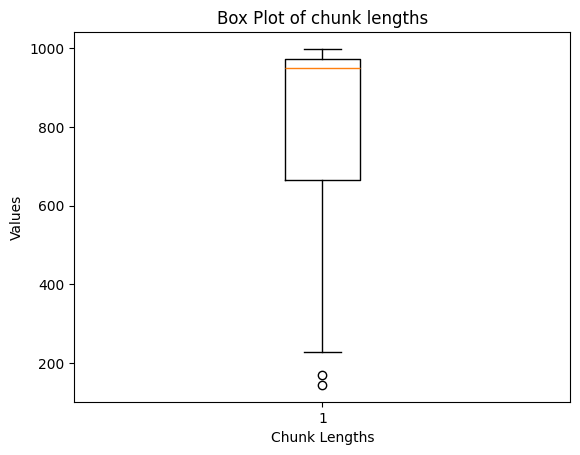

The median chunk lenght is : 949.0
The average chunk lenght is : 815.32
The minimum chunk lenght is : 144
The max chunk lenght is : 998
The 75th percentile chunk length is : 973.0
The 25th percentile chunk length is : 666.0


In [38]:
data = [len(doc.page_content) for doc in pdf_doc_chunks]

plt.boxplot(data)  
plt.title('Box Plot of chunk lengths')  # Title 
plt.xlabel('Chunk Lengths')  # Label for x-axis
plt.ylabel('Values')  # Label for y-axis

plt.show()

print(f"The median chunk lenght is : {round(np.median(data),2)}")
print(f"The average chunk lenght is : {round(np.mean(data),2)}")
print(f"The minimum chunk lenght is : {round(np.min(data),2)}")
print(f"The max chunk lenght is : {round(np.max(data),2)}")
print(f"The 75th percentile chunk length is : {round(np.percentile(data, 75),2)}")
print(f"The 25th percentile chunk length is : {round(np.percentile(data, 25),2)}")

### <span style="color:#47c7fc">Data Transformation or Embeddings</span>

#### __OpenAI Embeddings__

OpenAI, the company behind ChatGPT and GPT series of Large Language Models also provide three Embeddings Models. 

1.	text-embedding-ada-002 was released in December 2022. It has a dimension of 1536 meaning that it converts text into a vector of 1536 dimensions.
2.	text-embedding-3-small is the latest small embedding model of 1536 dimensions released in January 2024. The flexibility it provides over ada-002 model is that users can adjust the size of the dimensions according to their needs.
3.	text-embedding-3-large is a large embedding model of 3072 dimensions released together with the text-embedding-3-small model. It is the best performing model released by OpenAI yet.


OpenAI models are proprietary and can be accessed using the OpenAI API and are priced based on the number of input tokens for which embeddings are desired. 


Note: You will need an __OpenAI API Key__ which can be obtained from [OpenAI](https://platform.openai.com/api-keys)

To initialize the __OpenAI client__, we need to pass the api key. There are many ways of doing it. 

__[Option 1] Creating a .env file for storing the API key and using it # Recommended__

Install the __dotenv__ library

_The dotenv library is a popular tool used in various programming languages, including Python and Node.js, to manage environment variables in development and deployment environments. It allows developers to load environment variables from a .env file into their application's environment._

- Create a file named .env in the root directory of their project.
- Inside the .env file, then define environment variables in the format VARIABLE_NAME=value. 

e.g.

OPENAI_API_KEY=YOUR API KEY

In [39]:
from dotenv import load_dotenv
import os

if load_dotenv():
    print("Success: .env file found with some environment variables")
else:
    print("Caution: No environment variables found. Please create .env file in the root directory or add environment variables in the .env file")

Success: .env file found with some environment variables


We can also test if the key is valid or not

In [ ]:
# Test OpenAI Client Initialization
import os
import openai
from openai import OpenAI

print("🔧 Testing OpenAI Client Setup...")
print("-" * 40)

# Get API key from environment
api_key = os.environ.get("OPENAI_API_KEY")

if not api_key:
    print("⚠️  OPENAI_API_KEY tidak ditemukan!")
    print("💡 Pastikan Anda sudah mengatur environment variable OPENAI_API_KEY")
else:
    print("🔑 API Key ditemukan")
    
    try:
        # Initialize OpenAI client
        client = OpenAI(api_key=api_key)
        print("🤖 OpenAI client berhasil diinisialisasi")
        
        # Test connection dengan list models
        models = client.models.list()
        print("✅ Koneksi ke OpenAI API berhasil!")
        print(f"📊 Tersedia {len(list(models))} model")
        
        # Show beberapa model yang tersedia
        model_names = [model.id for model in models][:5]  # Ambil 5 model pertama
        print(f"🎯 Contoh model: {', '.join(model_names)}")
        
    except openai.APIError as e:
        print(f"❌ OpenAI API Error: {e}")
    except openai.APIConnectionError as e:
        print(f"❌ Koneksi gagal: {e}")
    except openai.RateLimitError as e:
        print(f"❌ Rate limit exceeded: {e}")
    except Exception as e:
        print(f"❌ Error tidak terduga: {type(e).__name__}: {e}")

print("-" * 40)
print("🏁 Test selesai!")



Now we will use the __OpenAIEmbeddings__ library from langchain 

In [41]:
# Import OpenAIEmbeddings from the library
from langchain_openai import OpenAIEmbeddings

os.environ["TOKENIZERS_PARALLELISM"]="false"

# Initialize embeddings with consistent variable name
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Generate embeddings for all document chunks
pdf_doc_embeddings = embeddings.embed_documents([chunk.page_content for chunk in pdf_doc_chunks])

print(f"Generated embeddings for {len(pdf_doc_chunks)} chunks")
print(f"Each embedding has {len(pdf_doc_embeddings[0])} dimensions")

Generated embeddings for 87 chunks
Each embedding has 1536 dimensions


In [42]:
print(f"The lenght of the embeddings vector is {len(pdf_doc_embeddings[0])}")
print(f"The embeddings object is an array of {len(pdf_doc_embeddings)} X {len(pdf_doc_embeddings[0])}")

The lenght of the embeddings vector is 1536
The embeddings object is an array of 87 X 1536


### <span style="color:#47c7fc">Vector Storage</span>

In [43]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

storage_file_path="./Memory"
storage_index_name="PDF_index"

index = faiss.IndexFlatIP(len(pdf_doc_embeddings[0]))

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

vector_store.add_documents(documents=pdf_doc_chunks)

['541e7b95-55ad-4df8-997c-dd998309e090',
 'fde0d0b7-338a-41c4-a613-164d1b689360',
 'c46794c4-fd28-490a-862f-38bc3d5f21e5',
 '16462a44-b715-4b71-bf47-08904f5b5b24',
 'f3fa6bcc-b2d9-4fa9-be34-769f1b183ff7',
 'a6e4303e-9392-4992-8d27-51bbea925e80',
 '0f7be2b7-7e43-4c55-b05c-0638d98ea5fc',
 '8d5f8ef3-82bb-4ed0-9fba-5a23f4e88c40',
 '100f4e01-4312-41ef-8089-971fa1be8c2c',
 '6f52dce6-4545-4a0e-a073-2afe64d0e2d9',
 '0e8eefb9-c7b1-4dd3-ad1b-1c78c78c99cc',
 'b80906d6-0a8a-4afc-801d-8d01d1673184',
 '5c882387-d2c2-43e5-b783-05fbee94677e',
 '913785d6-675d-4ab6-bae6-81660e69fc91',
 '52d21ddd-5e0b-4d20-aefe-f2f376ae6d1b',
 '4d140745-4bcd-4e48-b8b3-f4b494499e02',
 '5a12b871-8fc3-4f4c-b28a-2fa9ce4de23c',
 'abdb6ec6-8018-48e2-be1b-87cb7baf2448',
 '884caf8d-cfe5-48e0-a200-d88b7910a583',
 '8d66f51c-d106-41b6-8ae3-e3b25b460c9d',
 '2610388f-d5c3-461e-a59c-cd2d39220498',
 'c78349ba-fadb-41e0-8552-a53ff9066197',
 '57761c70-1cc9-4930-84e7-adc77a818dc8',
 'ae0c1102-bc67-45ac-8947-ff65b2a7c954',
 '8b09a8c8-96c6-

We can also save the vector store in persistent memory!

In [44]:
vector_store.save_local(folder_path=storage_file_path,index_name=storage_index_name)

## <span style="color:#ff8000">Generation Pipeline</span>

## <span style="color:#ff8000">1. Retrieval</span>

In [45]:
# Load the FAISS vector store with safe deserialization
vector_store = FAISS.load_local(folder_path="./Memory", index_name="PDF_index", embeddings=embeddings, allow_dangerous_deserialization=True)

# Define a query
query = "Apa saja tujuan umum dan khusus dari penyelenggaraan kegiatan MAPAK di ITB?"

# Perform similarity search
retrieved_docs = vector_store.similarity_search(query, k=2)  # Get top 2 relevant chunks

# Display results
for i, doc in enumerate(retrieved_docs):
    print(textwrap.fill(f"\nRetrieved Chunk {i+1}:\n{doc.page_content}",width=100))
    print("\n\n")

 Retrieved Chunk 1: secara berlebihan tidak dibenarkan dan dilarang keras. Kegiatan ini merupakan
tanggung  jawab institusi yang dilaksanakan oleh mahasiswa dengan pendampingan dari dosen dan
tenaga kependidikan. ITB berkomitmen membangun budaya akademik yang inklusif, suportif,  dan
beretika demi terciptanya lingkungan kampus yang sehat dan aman bagi seluruh  mahasiswa.  Dalam
pelaksanaan kegiatan MAPAK diperlukan kreativitas dan inovasi dalam persiapan,  penyelenggaraan
maupun penyelesaian kegiatan agar tujuan -tujuan bisa tetap dicapai  dengan optimalisasi sumber daya
yang tersedia serta meminimalkan dampak negatif. Untuk  itu ditetapkan beberapa hal sebagai panduan
pelaksanaan kegiatan MAPAK di lingkungan ITB  sebagai berikut.     jdih.itb.ac.id Dicetak
tanggal:06-08-2025 Akhmad Setiawan



 Retrieved Chunk 2: digunakan.  e. Perlindungan dan Keamanan, yaitu kegiatan diselenggarakan dalam
suasana  yang aman dan bebas dari segala bentuk kekerasan fisik, verbal, seksual,  psikologis, 

This is the most basic implementation of a retriever in the generation pipeline of a RAG-enabled system. This method of retrieval is enabled by embeddings. We used the text-embedding-3-small from OpenAI. FAISS calculated the similarity score based on these embeddings.

---

## <span style="color:#ff8000">2. Augmentation</span>

The information fetched by the retriever should also be sent to the LLM in form of a natural language prompt. This process of combining the user query and the retrieved information is called augmentation.


In [46]:
retrieved_context=retrieved_docs[0].page_content + retrieved_docs[1].page_content

# Creating the prompt
augmented_prompt=f"""

Given the context below answer the question.

Question: {query} 

Context : {retrieved_context}

Remember to answer only based on the context provided and not from any other source. 

If the question cannot be answered based on the provided context, say I don’t know.

"""

print(textwrap.fill(augmented_prompt,width=150))

  Given the context below answer the question.  Question: Apa saja tujuan umum dan khusus dari penyelenggaraan kegiatan MAPAK di ITB?   Context :
secara berlebihan tidak dibenarkan dan dilarang keras. Kegiatan ini merupakan tanggung  jawab institusi yang dilaksanakan oleh mahasiswa dengan
pendampingan dari dosen dan  tenaga kependidikan. ITB berkomitmen membangun budaya akademik yang inklusif, suportif,  dan beretika demi terciptanya
lingkungan kampus yang sehat dan aman bagi seluruh  mahasiswa.  Dalam pelaksanaan kegiatan MAPAK diperlukan kreativitas dan inovasi dalam persiapan,
penyelenggaraan maupun penyelesaian kegiatan agar tujuan -tujuan bisa tetap dicapai  dengan optimalisasi sumber daya yang tersedia serta meminimalkan
dampak negatif. Untuk  itu ditetapkan beberapa hal sebagai panduan pelaksanaan kegiatan MAPAK di lingkungan ITB  sebagai berikut.     jdih.itb.ac.id
Dicetak tanggal:06-08-2025 Akhmad Setiawandigunakan.  e. Perlindungan dan Keamanan, yaitu kegiatan diselenggarakan

---

## <span style="color:#ff8000">3. Generation</span>

Generation is the final step of this pipeline. While LLMs may be used in any of the previous steps in the pipeline, the generation step is completely reliant on the LLM. The most popular LLMs are the ones being developed by OpenAI, Anthropic, Meta, Google, Microsoft and Mistral amongst other developers. 

We have built a simple retriever using FAISS and OpenAI embeddings and, we created a simple augmented prompt. Now we will use OpenAI’s model, GPT-4.1-mini, to generate the response.

In [47]:
from langchain_openai import ChatOpenAI


# Set up LLM and embeddings
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
    timeout=None,
    max_retries=2
)

messages=[("human",augmented_prompt)]

ai_msg = llm.invoke(messages)
ai_msg.content

'Tujuan umum kegiatan MAPAK di ITB adalah memberikan pembekalan kepada mahasiswa baru agar dapat beradaptasi secara optimal dengan lingkungan akademik dan sosial di kampus ITB.\n\nTujuan khusus MAPAK adalah menanamkan kesadaran berbangsa, bernegara, bela negara, serta kepedulian terhadap lingkungan dan masyarakat sesuai dengan nilai-nilai Pancasila, UUD 1945, dan Bhineka Tunggal Ika.'

## <span style="color:#ff8000">Congratulations!</span>
For completing this introduction to RAG. I hope you had fun. For any queries, please get in touch!

## <span style="color:#ff8000">Testing the Complete RAG Pipeline</span>

Let's test the complete pipeline from indexing to generation with a comprehensive example.

In [ ]:
# Complete RAG Pipeline Test
def test_rag_pipeline():
    print("🔄 Testing Complete RAG Pipeline...")
    print("=" * 50)
    
    # 1. Test data loading
    print("1. Loading PDFs from ../data...")
    pdf_loader = DirectoryLoader(
        '../data', 
        glob="*.pdf",
        loader_cls=PyPDFLoader,
        use_multithreading=True
    )
    pdf_data = pdf_loader.load()
    print(f"✅ Loaded {len(pdf_data)} pages from PDF files")
    
    # 2. Test chunking
    print("\n2. Chunking documents...")
    text_splitter = RecursiveCharacterTextSplitter(
        separators=["\n\n","\n","."],
        chunk_size=1000,
        chunk_overlap=100,
    )
    pdf_doc_chunks = text_splitter.split_documents(pdf_data)
    print(f"✅ Created {len(pdf_doc_chunks)} chunks")
    
    # 3. Test embeddings
    print("\n3. Creating embeddings...")
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    print("✅ Embeddings model initialized")
    
    # 4. Test vector store creation
    print("\n4. Creating vector store...")
    import faiss
    from langchain_community.docstore.in_memory import InMemoryDocstore
    from langchain_community.vectorstores import FAISS
    
    index = faiss.IndexFlatIP(1536)  # dimension for text-embedding-3-small
    vector_store = FAISS(
        embedding_function=embeddings,
        index=index,
        docstore=InMemoryDocstore(),
        index_to_docstore_id={},
    )
    vector_store.add_documents(documents=pdf_doc_chunks)
    print("✅ Vector store created and populated")
    
    # 5. Save vector store
    print("\n5. Saving vector store...")
    vector_store.save_local(folder_path="./Memory", index_name="PDF_index")
    print("✅ Vector store saved to ./Memory/PDF_index")
    
    # 6. Test retrieval
    print("\n6. Testing retrieval...")
    test_query = "Apa saja jenis Layanan Kemahasiswaan yang disediakan ITB?"
    retrieved_docs = vector_store.similarity_search(test_query, k=3)
    print(f"✅ Retrieved {len(retrieved_docs)} relevant documents")
    
    # 7. Test generation
    print("\n7. Testing generation...")
    from langchain_openai import ChatOpenAI
    
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    
    # Create augmented prompt
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    augmented_prompt = f"""
    Berdasarkan konteks berikut, jawab pertanyaan dengan bahasa Indonesia.
    
    Pertanyaan: {test_query}
    
    Konteks: {context}
    
    Jawab hanya berdasarkan konteks yang diberikan. Jika tidak bisa dijawab berdasarkan konteks, katakan "Saya tidak tahu berdasarkan dokumen yang tersedia."
    """
    
    messages = [("human", augmented_prompt)]
    response = llm.invoke(messages)
    print("✅ Generated response from LLM")
    
    print("\n" + "=" * 50)
    print("🎉 RAG Pipeline Test Complete!")
    print("=" * 50)
    
    print(f"\n📊 Pipeline Statistics:")
    print(f"• Total pages loaded: {len(pdf_data)}")
    print(f"• Total chunks created: {len(pdf_doc_chunks)}")
    print(f"• Vector store dimension: 1536")
    print(f"• Test query: '{test_query}'")
    print(f"• Documents retrieved: {len(retrieved_docs)}")
    
    print(f"\n💬 Sample Response:")
    print("-" * 30)
    print(response.content[:500] + "..." if len(response.content) > 500 else response.content)
    
    return {
        'pages_loaded': len(pdf_data),
        'chunks_created': len(pdf_doc_chunks),
        'documents_retrieved': len(retrieved_docs),
        'response': response.content
    }

# Run the test
test_results = test_rag_pipeline()

## <span style="color:#ff8000">🚀 Enhanced Legal Prompt Engineering System</span>

This section implements an advanced prompt engineering system specifically designed for legal document analysis and Q&A.

In [ ]:
def create_legal_prompt_system(query: str, context: str, query_type: str = "general") -> str:
    """
    Enhanced prompt engineering system for legal document Q&A
    
    Args:
        query: User's legal question
        context: Retrieved document context
        query_type: Type of legal analysis needed
    
    Returns:
        Enhanced prompt for legal document analysis
    """
    
    # Legal role definitions
    legal_role_instructions = {
        "regulation_analysis": """
        Anda adalah seorang ahli hukum administrasi yang menganalisis peraturan dan kebijakan institusi.
        Fokus pada: struktur peraturan, hirarki hukum, dan implementasi praktis.
        """,
        "compliance_check": """
        Anda adalah konsultan compliance yang membantu memahami kepatuhan terhadap regulasi.
        Fokus pada: persyaratan, prosedur, dan konsekuensi pelanggaran.
        """,
        "rights_obligations": """
        Anda adalah legal advisor yang menjelaskan hak dan kewajiban stakeholder.
        Fokus pada: hak mahasiswa/dosen/staff, kewajiban institusi, dan perlindungan hukum.
        """,
        "procedural_guidance": """
        Anda adalah expert procedural yang memberikan panduan step-by-step.
        Fokus pada: proses administratif, timeline, dan requirement dokumen.
        """,
        "general": """
        Anda adalah asisten hukum yang memberikan informasi legal yang akurat dan mudah dipahami.
        Fokus pada: interpretasi yang tepat, konteks yang relevan, dan aplikasi praktis.
        """
    }
    
    # Context analysis instructions
    context_analysis = """
    ANALISIS KONTEKS:
    1. Identifikasi jenis dokumen (Surat Edaran, Peraturan, Pedoman, dll.)
    2. Perhatikan nomor dan tanggal dokumen untuk validitas
    3. Cari hierarki dan referensi ke dokumen lain
    4. Identifikasi stakeholder yang terdampak
    5. Perhatikan periode berlaku dan implementasi
    """
    
    # Output format specifications
    output_formats = {
        "regulation_analysis": """
        FORMAT JAWABAN:
        ## 📋 Ringkasan Peraturan
        [Poin-poin utama peraturan]
        
        ## ⚖️ Dasar Hukum
        [Referensi dan hierarki hukum]
        
        ## 🎯 Implementasi
        [Cara penerapan praktis]
        
        ## 📌 Catatan Penting
        [Hal-hal yang perlu diperhatikan]
        """,
        "compliance_check": """
        FORMAT JAWABAN:
        ## ✅ Status Compliance
        [COMPLIANT/NON-COMPLIANT/PARTIAL dengan alasan]
        
        ## 📋 Persyaratan
        [Daftar requirement yang harus dipenuhi]
        
        ## ⚠️ Risiko & Konsekuensi
        [Dampak jika tidak compliance]
        
        ## 🔧 Rekomendasi
        [Langkah-langkah perbaikan]
        """,
        "rights_obligations": """
        FORMAT JAWABAN:
        ## 👤 Hak Stakeholder
        [Daftar hak yang dilindungi]
        
        ## 📝 Kewajiban
        [Daftar kewajiban yang harus dipenuhi]
        
        ## 🛡️ Perlindungan Hukum
        [Mekanisme perlindungan yang tersedia]
        
        ## ⚖️ Penyelesaian Sengketa
        [Prosedur jika ada pelanggaran]
        """,
        "procedural_guidance": """
        FORMAT JAWABAN:
        ## 🗂️ Prosedur Step-by-Step
        [Langkah-langkah detail]
        
        ## 📅 Timeline
        [Batas waktu untuk setiap tahap]
        
        ## 📋 Dokumen Required
        [Daftar dokumen yang dibutuhkan]
        
        ## 👥 Pihak Terlibat
        [Siapa saja yang bertanggung jawab]
        """,
        "general": """
        FORMAT JAWABAN:
        ## 💡 Jawaban Utama
        [Jawaban langsung terhadap pertanyaan]
        
        ## 📖 Dasar Peraturan
        [Rujukan dokumen dan pasal]
        
        ## 🔍 Penjelasan Detail
        [Elaborasi dan konteks tambahan]
        
        ## ❓ FAQ Terkait
        [Pertanyaan umum seputar topik ini]
        """
    }
    
    # Legal analysis framework
    legal_framework = """
    KERANGKA ANALISIS HUKUM:
    1. VALIDITAS: Pastikan dokumen masih berlaku dan tidak dicabut
    2. HIERARKI: Pertimbangkan tingkat peraturan (UU, PP, Permendikbud, SE, dll.)
    3. HARMONISASI: Cek konsistensi dengan peraturan lain
    4. IMPLEMENTASI: Berikan panduan praktis penerapan
    5. COMPLIANCE: Identifikasi requirement dan konsekuensi
    """
    
    # Evidence and citation requirements
    citation_requirements = """
    PERSYARATAN SITASI:
    - Selalu sebutkan nomor dan judul dokumen
    - Cantumkan pasal/bagian spesifik jika relevan
    - Indikasikan jika ada dokumen pendukung
    - Berikan context tanggal berlaku
    - Gunakan format: [Nama Dokumen, Nomor, Tanggal]
    """
    
    # Build the complete prompt
    role_instruction = legal_role_instructions.get(query_type, legal_role_instructions["general"])
    output_format = output_formats.get(query_type, output_formats["general"])
    
    enhanced_prompt = f"""{role_instruction}

{context_analysis}

{legal_framework}

DOKUMEN REFERENSI:
{context}

PERTANYAAN: {query}

{output_format}

{citation_requirements}

INSTRUKSI KHUSUS:
- Gunakan bahasa Indonesia yang formal namun mudah dipahami
- Berikan contoh konkret jika memungkinkan
- Jika ada ambiguitas, sebutkan kemungkinan interpretasi
- Jika informasi tidak lengkap, nyatakan limitasi jawaban
- Prioritaskan akurasi hukum di atas kelengkapan
- Berikan disclaimer jika diperlukan konsultasi lebih lanjut

DISCLAIMER: Jawaban ini berdasarkan dokumen yang tersedia dan bukan merupakan nasihat hukum resmi."""

    return enhanced_prompt

print("✅ Enhanced Legal Prompt System loaded successfully!")

### <span style="color:#47c7fc">📚 Comprehensive Legal Query Templates</span>

Predefined query templates for different types of legal analysis scenarios.

In [ ]:
# Comprehensive Legal Query Templates
legal_query_templates = {
    "regulation_analysis": [
        "Jelaskan struktur dan hierarki peraturan tentang {topic}",
        "Apa dasar hukum yang mengatur {topic} di ITB?",
        "Bagaimana peraturan {doc_name} berkaitan dengan regulasi lain?",
        "Analisis implementasi peraturan {topic} dalam praktik",
        "Identifikasi perubahan atau update terbaru tentang {topic}"
    ],
    
    "compliance_check": [
        "Apakah {activity} sudah sesuai dengan peraturan yang berlaku?",
        "Apa saja persyaratan compliance untuk {process}?",
        "Bagaimana memastikan kepatuhan terhadap {regulation}?",
        "Apa konsekuensi jika melanggar ketentuan {topic}?",
        "Audit compliance checklist untuk {area}"
    ],
    
    "rights_obligations": [
        "Apa hak mahasiswa terkait {topic}?",
        "Apa kewajiban dosen dalam {context}?",
        "Bagaimana perlindungan hukum untuk {stakeholder} dalam {situation}?",
        "Hak dan kewajiban panitia {event}",
        "Mekanisme pengaduan untuk pelanggaran {topic}"
    ],
    
    "procedural_guidance": [
        "Bagaimana prosedur step-by-step untuk {process}?",
        "Dokumen apa saja yang diperlukan untuk {application}?",
        "Berapa lama timeline untuk {procedure}?",
        "Siapa saja pihak yang terlibat dalam {process}?",
        "Bagaimana alur persetujuan untuk {request}?"
    ],
    
    "academic_regulations": [
        "Peraturan akademik terkait penilaian dan kehadiran",
        "Kebijakan cuti akademik dan prosedurnya", 
        "Aturan penyelenggaraan ujian dan evaluasi",
        "Ketentuan plagiarisme dan sanksinya",
        "Prosedur banding nilai dan keberatan akademik"
    ],
    
    "student_affairs": [
        "Peraturan kegiatan kemahasiswaan dan organisasi",
        "Ketentuan beasiswa dan bantuan finansial",
        "Aturan asrama dan fasilitas mahasiswa",
        "Prosedur MAPAK dan orientasi mahasiswa baru",
        "Layanan konseling dan bimbingan mahasiswa"
    ]
}

# Sample Advanced Queries untuk JDIH
sample_legal_queries = [
    {
        "query": "Analisis lengkap peraturan MAPAK: apa saja yang dilarang, sanksi, dan mekanisme pengawasan",
        "type": "regulation_analysis",
        "complexity": "high"
    },
    {
        "query": "Evaluasi compliance kegiatan organisasi mahasiswa terhadap SE WRSD terbaru",
        "type": "compliance_check", 
        "complexity": "medium"
    },
    {
        "query": "Prosedur lengkap pengajuan cuti akademik: syarat, dokumen, timeline, dan pihak terlibat",
        "type": "procedural_guidance",
        "complexity": "medium"
    },
    {
        "query": "Hak mahasiswa dalam proses banding nilai dan mekanisme perlindungan hukumnya",
        "type": "rights_obligations",
        "complexity": "high"
    },
    {
        "query": "Panduan implementasi pembelajaran daring sesuai SE WRAA terbaru",
        "type": "procedural_guidance",
        "complexity": "low"
    }
]

print("✅ Legal query templates loaded!")
print(f"📊 Available template categories: {list(legal_query_templates.keys())}")
print(f"🎯 Sample queries available: {len(sample_legal_queries)}")

### <span style="color:#47c7fc">🔍 Multi-Layer Context Enhancement</span>

Advanced context enhancement with document metadata, classification, and relevance scoring.

In [ ]:
import re
from datetime import datetime

def classify_document_type(content):
    """Classify legal document type based on content"""
    content_lower = content.lower()
    
    if 'surat edaran' in content_lower:
        return "Surat Edaran (SE)"
    elif 'peraturan rektor' in content_lower:
        return "Peraturan Rektor"
    elif 'pedoman' in content_lower:
        return "Pedoman"
    elif 'panduan' in content_lower:
        return "Panduan"
    elif 'prosedur operasional' in content_lower or 'sop' in content_lower:
        return "SOP"
    elif 'keputusan rektor' in content_lower:
        return "Keputusan Rektor"
    elif 'peraturan' in content_lower:
        return "Peraturan"
    else:
        return "Dokumen Umum"

def determine_authority_level(content):
    """Determine legal authority level"""
    content_lower = content.lower()
    
    if 'rektor' in content_lower and 'wakil' not in content_lower:
        return "Tinggi (Level Rektor)"
    elif 'wakil rektor' in content_lower:
        return "Sedang (Level Wakil Rektor)"
    elif 'dekan' in content_lower:
        return "Menengah (Level Dekan)"
    elif 'direktur' in content_lower:
        return "Menengah (Level Direktur)"
    else:
        return "Administratif"

def extract_document_date(content):
    """Extract document date from content"""
    # Common date patterns in Indonesian documents
    date_patterns = [
        r'(\d{1,2}[-/]\d{1,2}[-/]\d{4})',  # DD-MM-YYYY or DD/MM/YYYY
        r'(\d{4}[-/]\d{1,2}[-/]\d{1,2})',  # YYYY-MM-DD or YYYY/MM/DD
        r'(\d{1,2}\s+\w+\s+\d{4})',       # DD Month YYYY
        r'tanggal[:\s]*(\d{1,2}[-/]\d{1,2}[-/]\d{4})',  # tanggal: DD-MM-YYYY
    ]
    
    for pattern in date_patterns:
        match = re.search(pattern, content, re.IGNORECASE)
        if match:
            return match.group(1)
    
    return "Tanggal tidak teridentifikasi"

def extract_document_number(content):
    """Extract document number from content"""
    # Pattern for document numbers (e.g., 184/IT1.B04/TU.09/2025)
    number_patterns = [
        r'Nomor[:\s]*(\d+[/\w.-]+)',
        r'No[.:\s]*(\d+[/\w.-]+)',
        r'(\d+/IT1\.[A-Z0-9]+/[A-Z0-9.]+/\d{4})',
    ]
    
    for pattern in number_patterns:
        match = re.search(pattern, content, re.IGNORECASE)
        if match:
            return match.group(1)
    
    return "Nomor tidak teridentifikasi"

def calculate_relevance_score(content, query):
    """Calculate basic relevance score based on keyword overlap"""
    query_words = set(query.lower().split())
    content_words = set(content.lower().split())
    
    # Remove common stop words
    stop_words = {'dan', 'atau', 'yang', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'dalam', 'adalah', 'ini', 'itu'}
    query_words = query_words - stop_words
    content_words = content_words - stop_words
    
    if not query_words:
        return 5  # neutral score
    
    overlap = len(query_words.intersection(content_words))
    score = min(10, max(1, (overlap / len(query_words)) * 10))
    
    return round(score, 1)

def enhance_context_with_metadata(retrieved_docs, query):
    """
    Enhance context with document metadata and relevance scoring
    """
    enhanced_context = []
    
    for i, doc in enumerate(retrieved_docs):
        # Extract metadata from document
        doc_type = classify_document_type(doc.page_content)
        authority_level = determine_authority_level(doc.page_content)
        doc_date = extract_document_date(doc.page_content)
        doc_number = extract_document_number(doc.page_content)
        relevance_score = calculate_relevance_score(doc.page_content, query)
        
        enhanced_chunk = f"""
=== DOKUMEN {i+1} ===
📄 Tipe: {doc_type}
🏛️ Tingkat Otoritas: {authority_level}
📅 Tanggal: {doc_date}
🔢 Nomor: {doc_number}
⭐ Relevansi: {relevance_score}/10

📝 Konten:
{doc.page_content}

{'=' * 80}
"""
        
        enhanced_context.append(enhanced_chunk)
    
    return "\n".join(enhanced_context)

print("✅ Context enhancement functions loaded!")
print("🔧 Available functions: classify_document_type, determine_authority_level, extract_document_date, calculate_relevance_score")

### <span style="color:#47c7fc">🚀 Enhanced RAG Legal Function</span>

Complete enhanced RAG system combining all improvements for legal document analysis.

In [ ]:
def enhanced_rag_legal(query: str, query_type: str = "general", k: int = 4):
    """
    Enhanced RAG specifically for legal documents with comprehensive analysis
    
    Args:
        query: Legal question to answer
        query_type: Type of legal analysis (regulation_analysis, compliance_check, etc.)
        k: Number of documents to retrieve
    
    Returns:
        Dictionary containing query analysis, response, and metadata
    """
    print(f"🔍 Processing legal query: '{query}'")
    print(f"📋 Query type: {query_type}")
    print(f"📄 Retrieving {k} documents...")
    
    try:
        # Step 1: Retrieve documents using existing vector store
        retrieved_docs = vector_store.similarity_search(query, k=k)
        print(f"✅ Retrieved {len(retrieved_docs)} documents")
        
        # Step 2: Enhance context with metadata
        enhanced_context = enhance_context_with_metadata(retrieved_docs, query)
        print("✅ Enhanced context with metadata")
        
        # Step 3: Create legal-specific prompt
        legal_prompt = create_legal_prompt_system(query, enhanced_context, query_type)
        print("✅ Created enhanced legal prompt")
        
        # Step 4: Generate response with legal framework
        llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.1)
        
        messages = [("human", legal_prompt)]
        response = llm.invoke(messages)
        print("✅ Generated legal analysis response")
        
        # Step 5: Extract document metadata for summary
        doc_metadata = []
        for doc in retrieved_docs:
            metadata = {
                'type': classify_document_type(doc.page_content),
                'authority': determine_authority_level(doc.page_content),
                'date': extract_document_date(doc.page_content),
                'number': extract_document_number(doc.page_content),
                'relevance': calculate_relevance_score(doc.page_content, query),
                'preview': doc.page_content[:200] + "..."
            }
            doc_metadata.append(metadata)
        
        return {
            'query': query,
            'query_type': query_type,
            'documents_analyzed': len(retrieved_docs),
            'response': response.content,
            'document_metadata': doc_metadata,
            'legal_framework_applied': True,
            'enhanced_context_used': True
        }
        
    except Exception as e:
        print(f"❌ Error in enhanced RAG legal processing: {str(e)}")
        return {
            'error': str(e),
            'query': query,
            'query_type': query_type
        }

def display_legal_analysis(result):
    """
    Display enhanced legal analysis results in a formatted way
    """
    if 'error' in result:
        print(f"❌ Error: {result['error']}")
        return
    
    print("\n" + "="*100)
    print(f"🏛️ ENHANCED LEGAL ANALYSIS RESULTS")
    print("="*100)
    
    print(f"\n📝 Query: {result['query']}")
    print(f"📋 Analysis Type: {result['query_type']}")
    print(f"📄 Documents Analyzed: {result['documents_analyzed']}")
    
    print(f"\n📊 Document Summary:")
    for i, doc in enumerate(result['document_metadata']):
        print(f"  {i+1}. {doc['type']} | {doc['authority']} | Relevance: {doc['relevance']}/10")
        print(f"     Date: {doc['date']} | Number: {doc['number']}")
    
    print(f"\n💡 LEGAL ANALYSIS:")
    print("-" * 50)
    print(result['response'])
    
    print("\n" + "="*100)

print("✅ Enhanced RAG Legal system ready!")
print("🎯 Use: enhanced_rag_legal(query, query_type, k) to analyze legal documents")

### <span style="color:#47c7fc">🧪 Comprehensive Testing Examples</span>

Test the enhanced legal RAG system with various query types and scenarios.

In [ ]:
# Comprehensive Testing of Enhanced Legal RAG System

print("🧪 TESTING ENHANCED LEGAL RAG SYSTEM")
print("="*80)

# Test different query types with sample queries
test_scenarios = [
    {
        "name": "MAPAK Compliance Analysis",
        "query": "Apa saja sanksi jika panitia MAPAK melanggar ketentuan yang dilarang keras?",
        "type": "compliance_check"
    },
    {
        "name": "Procedural Guidance",
        "query": "Bagaimana prosedur step-by-step untuk pengajuan cuti akademik mahasiswa?",
        "type": "procedural_guidance"
    },
    {
        "name": "Rights and Obligations",
        "query": "Apa hak mahasiswa dalam mendapatkan layanan kemahasiswaan di ITB?",
        "type": "rights_obligations"
    },
    {
        "name": "Regulation Analysis",
        "query": "Analisis struktur dan implementasi Surat Edaran WRAA tentang pembelajaran daring",
        "type": "regulation_analysis"
    }
]

# Function to run comprehensive tests
def run_legal_rag_tests():
    """Run comprehensive tests on the enhanced legal RAG system"""
    
    for i, scenario in enumerate(test_scenarios, 1):
        print(f"\n🔬 TEST {i}: {scenario['name']}")
        print("-" * 60)
        
        try:
            # Run enhanced RAG analysis
            result = enhanced_rag_legal(
                query=scenario['query'],
                query_type=scenario['type'],
                k=3
            )
            
            # Display results in a concise format
            if 'error' not in result:
                print(f"✅ Analysis completed successfully")
                print(f"📊 Documents analyzed: {result['documents_analyzed']}")
                print(f"📝 Query type: {result['query_type']}")
                print(f"💡 Response preview: {result['response'][:200]}...")
                
                # Show document types found
                doc_types = [doc['type'] for doc in result['document_metadata']]
                print(f"📄 Document types: {', '.join(set(doc_types))}")
                
            else:
                print(f"❌ Test failed: {result['error']}")
                
        except Exception as e:
            print(f"❌ Test failed with exception: {str(e)}")
        
        print("\n" + "="*60)

print("🎯 Ready to run tests! Execute: run_legal_rag_tests()")
print("📋 Available test scenarios:")
for i, scenario in enumerate(test_scenarios, 1):
    print(f"  {i}. {scenario['name']} ({scenario['type']})")

### <span style="color:#47c7fc">🎮 Interactive Legal Query Interface</span>

Try your own legal queries with the enhanced system!

In [ ]:
# Interactive Legal Query Interface
# Try your own legal questions here!

# Example 1: General legal query
query_example_1 = "Apa saja layanan kemahasiswaan yang disediakan ITB dan bagaimana cara mengaksesnya?"
query_type_1 = "general"

print("🔍 CONTOH QUERY 1: General Legal Information")
print(f"📝 Query: {query_example_1}")
print(f"📋 Type: {query_type_1}")
print("\n" + "="*80)

# Uncomment the line below to run this example
# result_1 = enhanced_rag_legal(query_example_1, query_type_1)
# display_legal_analysis(result_1)

print("\n" + "="*80)
print("🎯 YOUR TURN! Customize the variables below:")
print("="*80)

# ========================================
# CUSTOMIZE YOUR LEGAL QUERY HERE:
# ========================================

# Change these variables to test your own legal questions
your_query = "Sebutkan hal-hal yang dilarang keras untuk dilakukan oleh panitia selama kegiatan MAPAK"
your_query_type = "compliance_check"  # Options: general, regulation_analysis, compliance_check, rights_obligations, procedural_guidance

# Number of documents to retrieve (1-10)
num_documents = 3

print(f"📝 Your Query: {your_query}")
print(f"📋 Query Type: {your_query_type}")
print(f"📄 Documents to retrieve: {num_documents}")

print("\n🚀 To execute your query, uncomment and run the lines below:")
print("# result = enhanced_rag_legal(your_query, your_query_type, num_documents)")
print("# display_legal_analysis(result)")

# Uncomment these lines to execute your query:
# result = enhanced_rag_legal(your_query, your_query_type, num_documents)
# display_legal_analysis(result)

print("\n" + "="*80)
print("💡 QUERY TYPE GUIDE:")
print("• general: Basic legal information and explanations")
print("• regulation_analysis: Deep analysis of regulations and their structure")
print("• compliance_check: Compliance requirements and violation consequences")
print("• rights_obligations: Rights and duties of different stakeholders")
print("• procedural_guidance: Step-by-step procedures and processes")
print("="*80)